# 1.0 — EDA y Limpieza del Dataset Transaccional
**Proyecto:** Segmentación de Clientes — E-commerce de Ferretería (Tierra del Fuego)
**Autor:** Ian Gallego | Politécnico Malvinas Argentinas | 2026

---
Carga el dataset crudo `transacciones_ecommerce.csv`, audita su calidad y aplica el
preprocesamiento definido en `segmentacion.dataset.limpiar_dataset`. El resultado se
persiste en `data/interim/transacciones_limpias.parquet` para alimentar el notebook 2.

## 🗺️ Mapa del pipeline

```
                                    ┌─────────────────┐
                                    │  CSV crudo      │
                                    │  50.730 trans   │
                                    └────────┬────────┘
                                             │
                              ┌──────────────▼──────────────┐
                              │  NB1: EDA + limpieza        │  ← Estás aquí
                              │  → transacciones_limpias    │
                              └──────────────┬──────────────┘
                                             │
                              ┌──────────────▼──────────────┐
                              │  NB2: features RFM +        │
                              │       deflactación          │
                              │  → clientes_rfm             │
                              └──────────────┬──────────────┘
                                             │
                              ┌──────────────▼──────────────┐
                              │  NB3: EDA del dataset RFM   │
                              │  (correlaciones, B2B/B2C)   │
                              └──────────────┬──────────────┘
                                             │
                              ┌──────────────▼──────────────┐
                              │  NB4: Clustering ⭐         │
                              │  K-Means + DBSCAN + HC      │
                              │  → modelo + scaler          │
                              └──────────────┬──────────────┘
                                             │
                              ┌──────────────▼──────────────┐
                              │  NB5: Interpretación        │
                              │  → 4 segmentos comerciales  │
                              │  → estrategias por segmento │
                              └─────────────────────────────┘
```

**Resultado final esperado:** un Pareto comercial — el 14 % de los clientes (Campeones B2B)
explica el 73 % de la facturación. Sobre eso se diseñan las estrategias de marketing.

## 1. Carga del dataset crudo

In [1]:
# Setup: agregar el root del proyecto al sys.path para importar segmentacion/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from segmentacion.dataset import cargar_transacciones, limpiar_dataset, guardar_intermedio
from segmentacion.config import FIGURES_DIR

df = cargar_transacciones()
print(f'Shape: {df.shape}')
df.head()

2026-06-03 20:01:33.745 | INFO     | segmentacion.config:<module>:11 - PROJ_ROOT path is: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut


2026-06-03 20:01:36.381 | INFO     | segmentacion.dataset:cargar_transacciones:37 - Cargadas 50,730 transacciones desde F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\raw\transacciones_ecommerce.csv
Shape: (50730, 9)


,id_transaccion,id_cliente,fecha,categoria_producto,cantidad_items,monto_total,canal_venta,medio_pago,localidad
0,TX-000001,CLI-00514,2024-06-02,Herramientas manuales,3,35488.78,Web,Tarjeta de débito,Tolhuin
1,TX-000003,CLI-05671,2024-06-03,Seguridad e indumentaria,4,176857.58,App,Cuenta corriente,Río Grande
2,TX-000004,CLI-01439,2024-06-05,Maderas y tableros,4,50604.82,Web,Tarjeta de crédito,Río Grande
3,TX-000006,CLI-05345,2024-06-06,Pinturas y revestimientos,3,45027.38,Web,T. débito,Ushuaia
4,TX-000007,CLI-05417,2024-06-07,Aberturas,2,136571.52,App,Efectivo en sucursal,Río Grande


## 2. Inspección inicial — tipos, nulos, rango temporal

In [2]:
print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Nulos por columna ===')
print(df.isnull().sum())
print(f'\nDuplicados exactos: {df.duplicated().sum()}')
print(f'Rango de fechas: {df.fecha.min().date()} -> {df.fecha.max().date()}')
print(f'Clientes unicos: {df.id_cliente.nunique():,}')

=== Tipos de datos ===
id_transaccion                object
id_cliente                    object
fecha                 datetime64[ns]
categoria_producto            object
cantidad_items                 int64
monto_total                  float64
canal_venta                   object
medio_pago                    object
localidad                     object
dtype: object

=== Nulos por columna ===
id_transaccion          0
id_cliente              0
fecha                   0
categoria_producto    131
cantidad_items          0
monto_total           355
canal_venta             0
medio_pago            585
localidad             204
dtype: int64

Duplicados exactos: 75
Rango de fechas: 2024-06-02 -> 2026-05-31
Clientes unicos: 5,000


In [3]:
print('=== Estadisticos numericos ===')
df[['cantidad_items', 'monto_total']].describe().round(2)

=== Estadisticos numericos ===


,cantidad_items,monto_total
count,50730.00,50375.00
mean,9.75,285663.43
std,14.34,570051.27
min,1.00,-3522045.33
25%,3.00,49179.54
50%,5.00,121140.12
75%,11.00,310362.44
max,300.00,37383912.23


## 3. Visualización de problemas de calidad

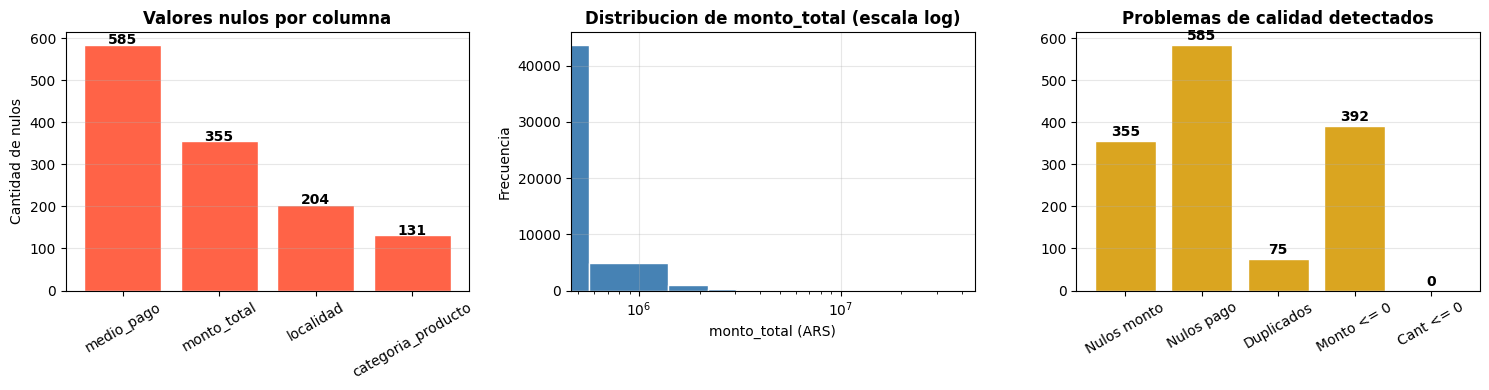

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 3.1 Nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
axes[0].bar(nulos.index, nulos.values, color='tomato', edgecolor='white')
axes[0].set_title('Valores nulos por columna', fontweight='bold')
axes[0].set_ylabel('Cantidad de nulos')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)
for i, (lbl, v) in enumerate(nulos.items()):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 3.2 Distribución monto_total (escala log)
axes[1].hist(df['monto_total'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Distribucion de monto_total (escala log)', fontweight='bold')
axes[1].set_xlabel('monto_total (ARS)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

# 3.3 Conteo de filas con problemas
problemas = {
    'Nulos monto': int(df['monto_total'].isnull().sum()),
    'Nulos pago':  int(df['medio_pago'].isnull().sum()),
    'Duplicados':  int(df.duplicated().sum()),
    'Monto <= 0':  int((df['monto_total'].fillna(1) <= 0).sum()),
    'Cant <= 0':   int((df['cantidad_items'] <= 0).sum()),
}
axes[2].bar(problemas.keys(), problemas.values(), color='goldenrod', edgecolor='white')
axes[2].set_title('Problemas de calidad detectados', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(problemas.values()):
    axes[2].text(i, v + max(problemas.values())*0.02, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb1_problemas_calidad.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.1 Variantes ortográficas detectadas (a normalizar en la limpieza)
El dataset sintético introduce intencionalmente variantes en columnas categóricas:
espacios, mayúsculas y typos en `localidad`, abreviaturas en `medio_pago`. La
función `limpiar_dataset` aplica las normalizaciones canónicas correspondientes.

In [5]:
print('Valores únicos de localidad ANTES de la limpieza:')
print(df['localidad'].value_counts(dropna=False))
print()
print('Valores únicos de medio_pago ANTES de la limpieza:')
print(df['medio_pago'].value_counts(dropna=False))

Valores únicos de localidad ANTES de la limpieza:
localidad
Río Grande     22530
Ushuaia        16425
Tolhuin         3852
RÍO GRANDE      1673
río grande      1312
USHUAIA         1138
Rio Grande      1103
ushuaia          917
Río Grande       565
Ushuaia          409
TOLHUIN          256
tolhuin          245
NaN              204
Tolhuin           83
Tohluin           18
Name: count, dtype: int64

Valores únicos de medio_pago ANTES de la limpieza:
medio_pago
Transferencia           14210
Cuenta corriente        12255
Tarjeta de crédito       9868
Tarjeta de débito        9838
Efectivo en sucursal     2561
transf.                   619
NaN                       585
T. crédito                403
T. débito                 391
Name: count, dtype: int64


### 3.2 Outliers B2B extremos (NO se eliminan — son legítimos según el README)
El README documenta `~150 compras masivas` de obras grandes (constructoras y
contratistas). Identificamos los más extremos: representan el segmento Campeones
del análisis posterior, NO errores de carga. El `log1p` aplicado a Monetary los
comprime para evitar que dominen el clustering.

In [6]:
outliers_extremos = df[df['monto_total'] > 10_000_000].copy()
outliers_extremos = outliers_extremos.sort_values('monto_total', ascending=False)
print(f'Outliers con monto > 10M ARS: {len(outliers_extremos)}')
outliers_extremos[['id_transaccion', 'id_cliente', 'fecha', 'categoria_producto', 'cantidad_items', 'monto_total']]

Outliers con monto > 10M ARS: 10


,id_transaccion,id_cliente,fecha,categoria_producto,cantidad_items,monto_total
44648,TX-055879,CLI-02311,2026-03-25,Aberturas,7,37383912.23
29714,TX-037078,CLI-00132,2025-10-17,Herramientas eléctricas,9,28379375.54
25768,TX-032125,CLI-06307,2025-08-20,Herramientas eléctricas,6,24195182.28
25945,TX-032368,CLI-00183,2025-08-23,Cemento y áridos,68,22256791.40
31180,TX-038922,CLI-04542,2025-11-04,Maderas y tableros,219,15968035.67
45413,TX-056733,CLI-03800,2026-04-01,Aberturas,10,15495056.59
35258,TX-043934,CLI-01576,2025-12-18,Aberturas,5,15337593.82
29050,TX-036390,CLI-05105,2025-10-10,Cemento y áridos,25,11457405.22
36755,TX-045747,CLI-01542,2026-01-02,Cemento y áridos,31,11136994.62
8822,TX-011058,CLI-05205,2024-12-22,Maderas y tableros,194,11041127.73


## 4. Limpieza
Aplicamos `limpiar_dataset` que:
- elimina duplicados exactos
- elimina filas con `monto_total` nulo (variable critica para Monetary)
- imputa `medio_pago` nulo con 'Desconocido'
- filtra montos y cantidades no positivas

In [7]:
df_limpio = limpiar_dataset(df)
print(f'\nShape final: {df_limpio.shape}')
print(f'Clientes unicos tras limpieza: {df_limpio.id_cliente.nunique():,}')
df_limpio.head()

2026-06-03 20:01:37.610 | INFO     | segmentacion.dataset:limpiar_dataset:88 - Limpieza: 50,730 -> 49,909 filas. Duplicados eliminados: 75, nulos monto eliminados: 355, nulos localidad imputados: 202, nulos pago imputados: 581, nulos categoria imputados: 128, no positivos filtrados: 391

Shape final: (49909, 9)
Clientes unicos tras limpieza: 4,992


,id_transaccion,id_cliente,fecha,categoria_producto,cantidad_items,monto_total,canal_venta,medio_pago,localidad
0,TX-000001,CLI-00514,2024-06-02,Herramientas manuales,3,35488.78,Web,Tarjeta de débito,Tolhuin
1,TX-000003,CLI-05671,2024-06-03,Seguridad e indumentaria,4,176857.58,App,Cuenta corriente,Río Grande
2,TX-000004,CLI-01439,2024-06-05,Maderas y tableros,4,50604.82,Web,Tarjeta de crédito,Río Grande
3,TX-000006,CLI-05345,2024-06-06,Pinturas y revestimientos,3,45027.38,Web,Tarjeta de débito,Ushuaia
4,TX-000007,CLI-05417,2024-06-07,Aberturas,2,136571.52,App,Efectivo en sucursal,Río Grande


In [8]:
print('Valores únicos de localidad DESPUES de la limpieza:')
print(df_limpio['localidad'].value_counts())
print()
print('Valores únicos de medio_pago DESPUES de la limpieza:')
print(df_limpio['medio_pago'].value_counts())
print()
print(f'Nulos en categoria_producto: {df_limpio.categoria_producto.isnull().sum()}')
print(f'Filas con monto_total <= 0: {(df_limpio.monto_total <= 0).sum()}')

Valores únicos de localidad DESPUES de la limpieza:
localidad
Río Grande     26728
Ushuaia        18591
Tolhuin         4390
Desconocido      200
Name: count, dtype: int64

Valores únicos de medio_pago DESPUES de la limpieza:
medio_pago
Transferencia           14580
Cuenta corriente        12044
Tarjeta de crédito      10129
Tarjeta de débito       10063
Efectivo en sucursal     2518
Desconocido               575
Name: count, dtype: int64

Nulos en categoria_producto: 0
Filas con monto_total <= 0: 0


In [9]:
# Verificar si se perdieron clientes tras la limpieza
clientes_antes = df.id_cliente.nunique()
clientes_despues = df_limpio.id_cliente.nunique()
perdidos = clientes_antes - clientes_despues
print(f'Clientes antes: {clientes_antes:,}  |  Clientes despues: {clientes_despues:,}  |  Perdidos: {perdidos}')
if perdidos > 0:
    ids_antes = set(df.id_cliente.unique())
    ids_despues = set(df_limpio.id_cliente.unique())
    ids_perdidos = ids_antes - ids_despues
    print(f'Cliente(s) eliminado(s): {ids_perdidos}')
    print('Motivo: todas sus transacciones tenian monto_total nulo o negativo (devoluciones).')
    print('Al filtrar filas no positivas, este cliente queda sin transacciones validas.')


Clientes antes: 5,000  |  Clientes despues: 4,992  |  Perdidos: 8
Cliente(s) eliminado(s): {'CLI-04858', 'CLI-02792', 'CLI-04755', 'CLI-02331', 'CLI-04551', 'CLI-04157', 'CLI-01053', 'CLI-03697'}
Motivo: todas sus transacciones tenian monto_total nulo o negativo (devoluciones).
Al filtrar filas no positivas, este cliente queda sin transacciones validas.


## 5. Persistencia

In [10]:
path = guardar_intermedio(df_limpio)
print(f'Listo. Archivo intermedio: {path}')

2026-06-03 20:01:37.976 | SUCCESS  | segmentacion.dataset:guardar_intermedio:101 - Guardado intermedio: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\interim\transacciones_limpias.parquet
Listo. Archivo intermedio: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\interim\transacciones_limpias.parquet


## 6. Visualización del efecto de log1p sobre outliers

El log1p comprime la escala de los outliers extremos (B2B). Aquí se ve cómo, en escala
lineal, los 3 outliers extremos dominan el gráfico, mientras que tras log1p quedan en un
rango comparable al resto. Esto permite que el clustering K-Means no se vea dominado por
ellos, pero sigan presentes para identificar el segmento Campeones.

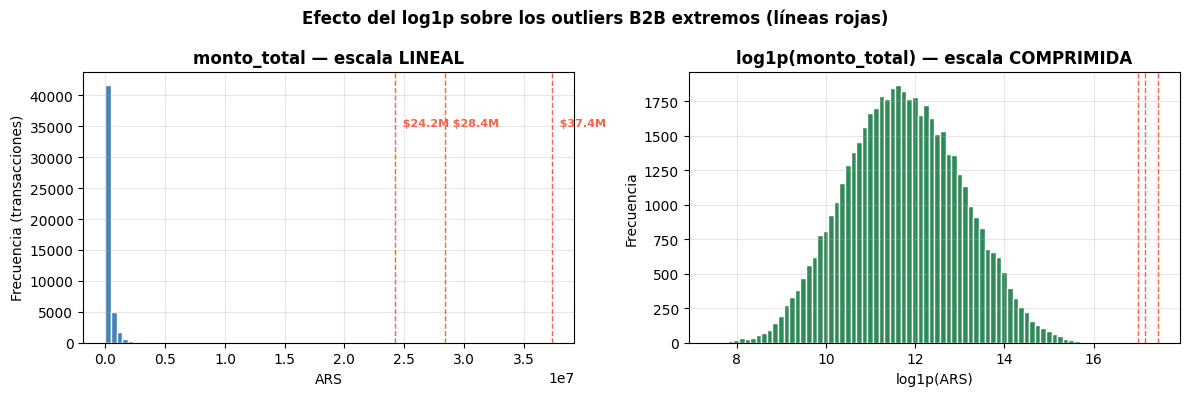

In [11]:
import numpy as np

muestra = df_limpio['monto_total'].values
outliers_idx = np.argsort(muestra)[-3:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(muestra, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('monto_total — escala LINEAL', fontweight='bold')
axes[0].set_xlabel('ARS')
axes[0].set_ylabel('Frecuencia (transacciones)')
axes[0].grid(alpha=0.3)
for i in outliers_idx:
    val = muestra[i]
    axes[0].axvline(val, color='tomato', linestyle='--', linewidth=1)
    axes[0].text(val, axes[0].get_ylim()[1]*0.8, f'  ${val/1e6:.1f}M',
                 color='tomato', fontsize=8, fontweight='bold')

axes[1].hist(np.log1p(muestra), bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(monto_total) — escala COMPRIMIDA', fontweight='bold')
axes[1].set_xlabel('log1p(ARS)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)
for i in outliers_idx:
    val = np.log1p(muestra[i])
    axes[1].axvline(val, color='tomato', linestyle='--', linewidth=1)

fig.suptitle('Efecto del log1p sobre los outliers B2B extremos (líneas rojas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb1_log1p_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔜 Próximo paso (notebook 2)

El notebook **2.0-ig-features-rfm** toma el dataset limpio que acabamos de guardar y:
1. **Agrupa por cliente** para construir la tabla RFM (recency, frequency, monetary + complementarias)
2. **Aplica deflactación por inflación** al campo `monto_total` — paso crítico porque el dataset
   modela inflación a lo largo de 24 meses; sin deflactar, los clientes recientes aparecerían
   artificialmente más valiosos solo por el efecto del alza de precios.
3. **Persiste la tabla cliente** en `data/processed/clientes_rfm.parquet` para alimentar el EDA y
   el clustering posteriores.

## 📋 TL;DR del notebook 1
- **Entrada:** `data/raw/transacciones_ecommerce.csv` (50.730 transacciones)
- **Salida:** `data/interim/transacciones_limpias.parquet` (49.909 filas)
- **Decisión clave:** **NO eliminar** los 10 outliers extremos (>$10M ARS) — son clientes B2B legítimos
- **Normalizaciones aplicadas:** `localidad` (4 valores canónicos), `medio_pago` (6 canónicos)
- **Siguiente paso:** notebook 2 → construir features RFM + deflactar por inflación